In [1]:
import pandas as pd

movies = pd.read_csv("../data/raw/ml-32m/movies.csv")
ratings = pd.read_csv("../data/raw/ml-32m/ratings.csv")

print(movies.shape)
print(ratings.shape)

(87585, 3)
(32000204, 4)


In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [5]:
movies.info(); print("\n", "."*40, "\n"); ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  87585 non-null  int64 
 1   title    87585 non-null  object
 2   genres   87585 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB

 ........................................ 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB


In [6]:
# we saw multiple genres for one movie
movies["genres"].head(10)

0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
5                          Action|Crime|Thriller
6                                 Comedy|Romance
7                             Adventure|Children
8                                         Action
9                      Action|Adventure|Thriller
Name: genres, dtype: object

In [7]:
# also the timestamps are seconds from Jan 1, 1970
ratings["timestamp"]
# need to cinvert it to datetime

0            944249077
1            944250228
2            943230976
3            944249077
4            943228858
               ...    
32000199    1294412589
32000200    1287216292
32000201    1294412671
32000202    1350423800
32000203    1350423523
Name: timestamp, Length: 32000204, dtype: int64

In [8]:
ratings["date"] = pd.to_datetime(
    ratings["timestamp"], unit="s"
)

print(ratings["date"].min())
print(ratings["date"].max())

1995-01-09 11:46:44
2023-10-13 02:29:07


In [9]:
ratings["date"].dt.year.value_counts().sort_index()

date
1995          4
1996    1571368
1997     685388
1998     301691
1999    1174629
2000    1912322
2001    1160098
2002     849762
2003    1011000
2004    1139068
2005    1752573
2006    1141704
2007    1023813
2008    1117071
2009     890696
2010     860073
2011     729301
2012     695493
2013     563301
2014     518537
2015    1743866
2016    1918739
2017    1827953
2018    1391057
2019    1385467
2020    1688159
2021    1239912
2022     913105
2023     794054
Name: count, dtype: int64

In [10]:
print(movies.shape)
print(ratings.shape)
print(ratings["date"].min())
print(ratings["date"].max())
print(movies.head())
print(ratings.head())

(87585, 3)
(32000204, 5)
1995-01-09 11:46:44
2023-10-13 02:29:07
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp                date
0       1       17     4.0  944249077 1999-12-03 19:24:37
1       1       25     1.0  944250228 1999-12-03 19:43:48
2       1       29     2.0  943230976 1999-11-22 00:36:16
3       1       30     5.0  944249077 1999-12-03 19:24:37
4       1       32     5.0  943228858 1999-11-22 0

In [11]:
# All unique genres
genres = movies["genres"].str.split("|").explode().unique()

print(sorted(genres))

['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [12]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

print(genre_counts)

genres
Drama                 34175
Comedy                23124
Thriller              11823
Romance               10369
Action                 9668
Documentary            9363
Horror                 8654
(no genres listed)     7080
Crime                  6976
Adventure              5402
Sci-Fi                 4907
Animation              4617
Children               4520
Mystery                4013
Fantasy                3851
War                    2325
Western                1696
Musical                1059
Film-Noir               353
IMAX                    195
Name: count, dtype: int64


In [13]:
selected_genres = ["Action", "Comedy", "Drama", "Horror", "Sci-Fi", "Romance", "Thriller", "Animation"]

movie_genres = movies[["movieId", "genres"]].copy()

movie_genres["genres"] = movie_genres["genres"].str.split("|")

movie_genres = movie_genres.explode("genres")

movie_genres = movie_genres[
    movie_genres["genres"].isin(selected_genres)
]

print(movie_genres.shape)
print(movie_genres.head(10))

(107337, 2)
   movieId     genres
0        1  Animation
0        1     Comedy
2        3     Comedy
2        3    Romance
3        4     Comedy
3        4      Drama
3        4    Romance
4        5     Comedy
5        6     Action
5        6   Thriller


In [14]:
ratings_genre = ratings.merge(
    movie_genres,
    on="movieId",
    how="inner"
)

print(ratings_genre.shape)
print(ratings_genre.head())

(59473703, 6)
   userId  movieId  rating  timestamp                date   genres
0       1       17     4.0  944249077 1999-12-03 19:24:37    Drama
1       1       17     4.0  944249077 1999-12-03 19:24:37  Romance
2       1       25     1.0  944250228 1999-12-03 19:43:48    Drama
3       1       25     1.0  944250228 1999-12-03 19:43:48  Romance
4       1       29     2.0  943230976 1999-11-22 00:36:16    Drama


In [15]:
ratings_genre["month"] = ratings_genre["date"].dt.to_period("M")

monthly = (
    ratings_genre.groupby(["month", "genres"]).size().reset_index(name="ratings")
)

monthly.head()

,month,genres,ratings
0,1995-01,Comedy,2
1,1995-01,Drama,1
2,1995-01,Romance,1
3,1995-01,Thriller,2
4,1996-01,Action,5


In [16]:
print(monthly["genres"].unique())

['Comedy' 'Drama' 'Romance' 'Thriller' 'Action' 'Animation' 'Horror'
 'Sci-Fi']


In [17]:
monthly["total_ratings"] = (
    monthly.groupby("month")["ratings"]
    .transform("sum")
)

monthly["popularity"] = (
    monthly["ratings"] / monthly["total_ratings"] * 100
)

In [18]:
check = monthly.groupby("month")["popularity"].sum()

print(check.head())
print(check.min(), check.max())

month
1995-01    100.0
1996-01    100.0
1996-02    100.0
1996-03    100.0
1996-04    100.0
Freq: M, Name: popularity, dtype: float64
99.99999999999999 100.00000000000001


In [19]:
print(ratings_genre.shape)
print(monthly.shape)
print(monthly.head(10))
print(check.min(), check.max())

(59473703, 7)
(2668, 5)
     month     genres  ratings  total_ratings  popularity
0  1995-01     Comedy        2              6   33.333333
1  1995-01      Drama        1              6   16.666667
2  1995-01    Romance        1              6   16.666667
3  1995-01   Thriller        2              6   33.333333
4  1996-01     Action        5             81    6.172840
5  1996-01  Animation        2             81    2.469136
6  1996-01     Comedy       21             81   25.925926
7  1996-01      Drama       18             81   22.222222
8  1996-01     Horror        3             81    3.703704
9  1996-01    Romance       10             81   12.345679
99.99999999999999 100.00000000000001


In [20]:
monthly_activity = (
    monthly.groupby("month")["total_ratings"]
    .first()
)

print(monthly_activity.head(20))
print(monthly_activity.tail(20))

month
1995-01         6
1996-01        81
1996-02       789
1996-03     16587
1996-04     93480
1996-05    335984
1996-06    476161
1996-07    409059
1996-08    396764
1996-09    276006
1996-10    348998
1996-11    339574
1996-12    241601
1997-01    194885
1997-02    119281
1997-03    179505
1997-04    151172
1997-05    171644
1997-06    147057
1997-07    101884
Freq: M, Name: total_ratings, dtype: int64
month
2022-03    136764
2022-04    144822
2022-05    120996
2022-06    130996
2022-07    116810
2022-08    149456
2022-09    126716
2022-10    118685
2022-11    137981
2022-12    150208
2023-01    187279
2023-02    141987
2023-03    148901
2023-04    140685
2023-05    143172
2023-06    125604
2023-07    166199
2023-08    179444
2023-09    176477
2023-10     63151
Freq: M, Name: total_ratings, dtype: int64


In [21]:
print(monthly_activity.describe())

count       334.000000
mean     178064.979042
std      105860.974188
min           6.000000
25%      115953.500000
50%      158436.500000
75%      222210.750000
max      804866.000000
Name: total_ratings, dtype: float64


In [22]:
for threshold in [100, 500, 1000, 5000, 10000]:
    months = monthly_activity[monthly_activity >= threshold]
    print(threshold, months.index.min())

100 1996-02
500 1996-02
1000 1996-03
5000 1996-03
10000 1996-03


In [23]:
ts = monthly.pivot(
    index="month",
    columns="genres",
    values="popularity"
)

ts = ts.sort_index()

print(ts.shape)
print(ts.head())

(334, 8)
genres      Action  Animation     Comedy      Drama    Horror    Romance  \
month                                                                      
1995-01        NaN        NaN  33.333333  16.666667       NaN  16.666667   
1996-01   6.172840   2.469136  25.925926  22.222222  3.703704  12.345679   
1996-02   9.505703   2.027883  20.278834  30.671736  2.788340  16.096324   
1996-03  15.072044   2.001567  20.516067  27.171882  2.025683  12.136010   
1996-04  16.071887   2.636928  20.415062  25.340180  2.016474  11.399230   

genres     Sci-Fi   Thriller  
month                         
1995-01       NaN  33.333333  
1996-01  4.938272  22.222222  
1996-02  2.661597  15.969582  
1996-03  6.089106  14.987641  
1996-04  5.931750  16.188490  


In [24]:
ts = ts.loc["1996-03":"2023-10"]

In [25]:
print(ts.shape)
print(ts.head())
print(ts.tail())

(331, 8)
genres      Action  Animation     Comedy      Drama    Horror    Romance  \
month                                                                      
1996-03  15.072044   2.001567  20.516067  27.171882  2.025683  12.136010   
1996-04  16.071887   2.636928  20.415062  25.340180  2.016474  11.399230   
1996-05  16.323992   3.199557  19.468189  23.704403  2.553098  10.849326   
1996-06  16.195573   3.076060  20.278645  23.062578  2.348155  11.796010   
1996-07  16.726194   2.685187  19.928421  22.568383  2.252976  11.783386   

genres     Sci-Fi   Thriller  
month                         
1996-03  6.089106  14.987641  
1996-04  5.931750  16.188490  
1996-05  6.124696  17.776739  
1996-06  5.901155  17.341823  
1996-07  6.360941  17.694514  
genres      Action  Animation     Comedy      Drama    Horror   Romance  \
month                                                                     
2023-06  17.445304   5.827840  16.927009  21.872711  5.566702  6.716347   
2023-07  17.1655

In [26]:
print(ts.isna().sum())

genres
Action       0
Animation    0
Comedy       0
Drama        0
Horror       0
Romance      0
Sci-Fi       0
Thriller     0
dtype: int64


In [27]:
# EDAaaaaaaaaaaaaa..........

In [28]:
import matplotlib.pyplot as plt

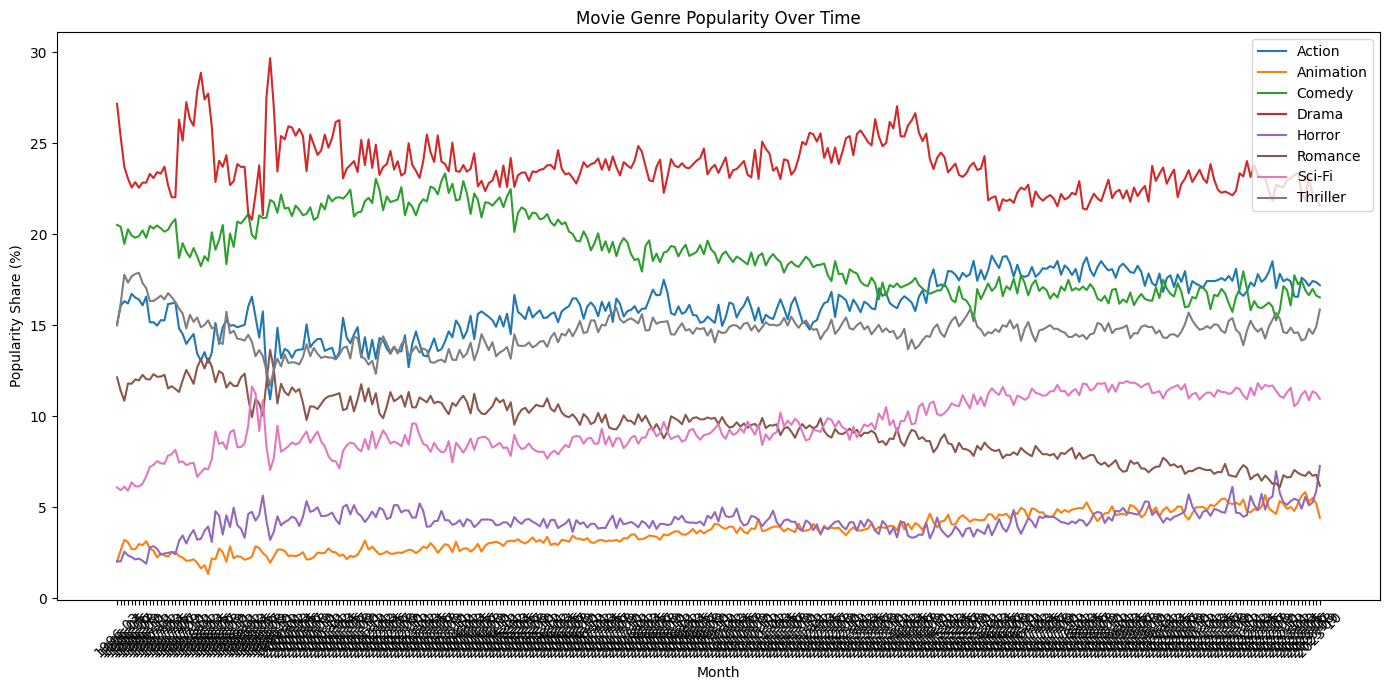

In [29]:
plt.figure(figsize=(14, 7))

for genre in ts.columns:
    plt.plot(ts.index.astype(str), ts[genre], label=genre)

plt.xlabel("Month")
plt.ylabel("Popularity Share (%)")
plt.title("Movie Genre Popularity Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

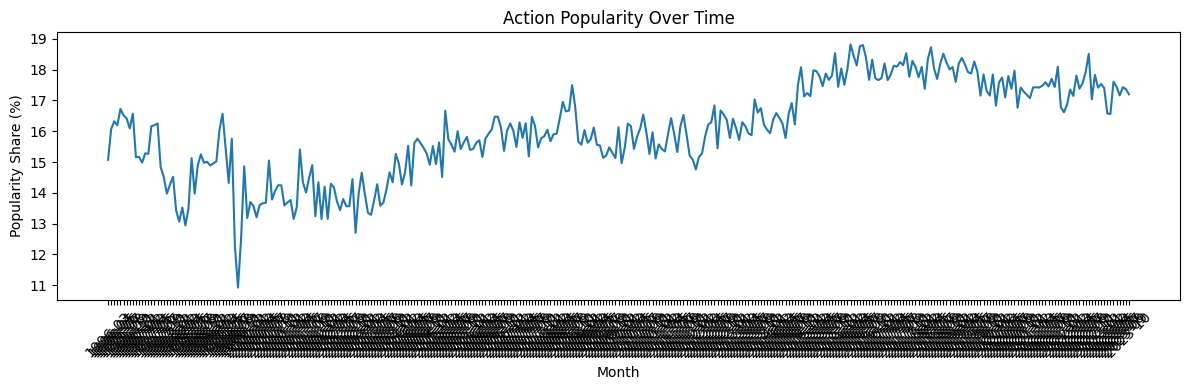

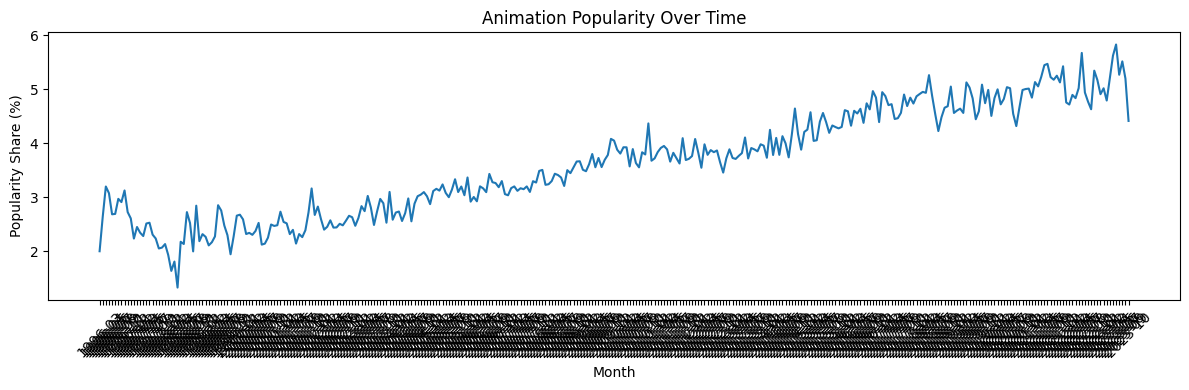

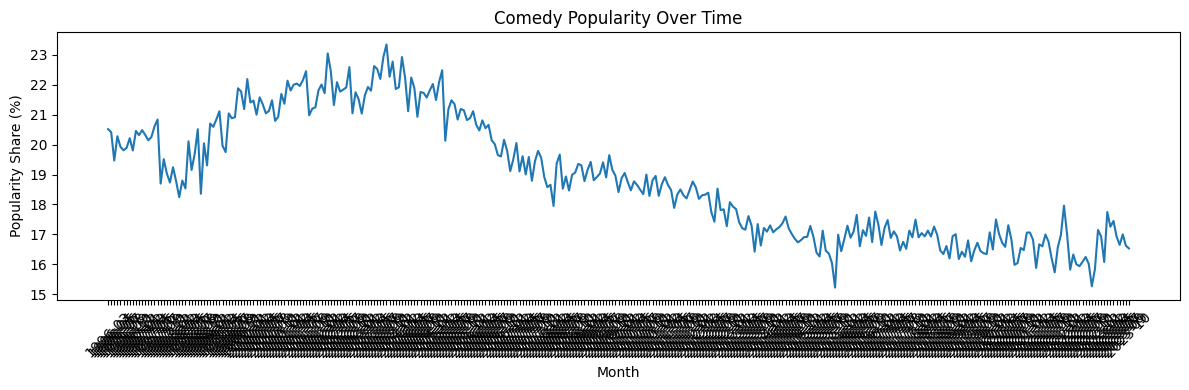

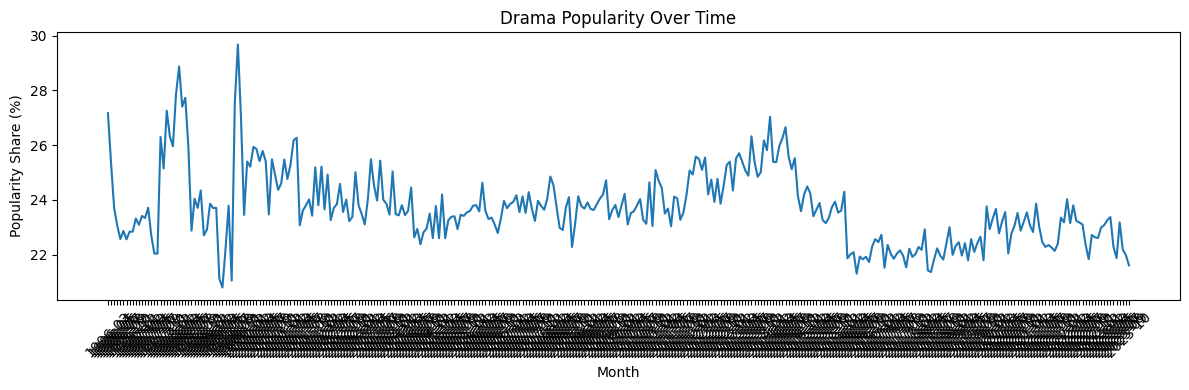

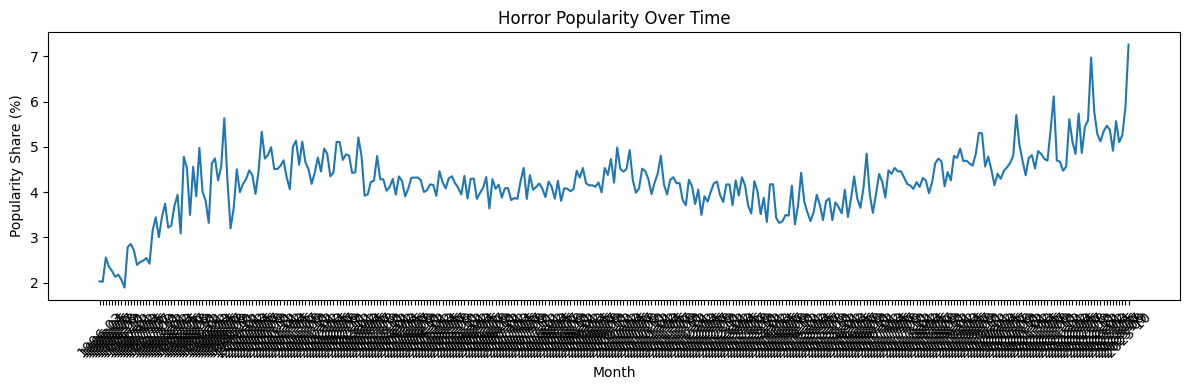

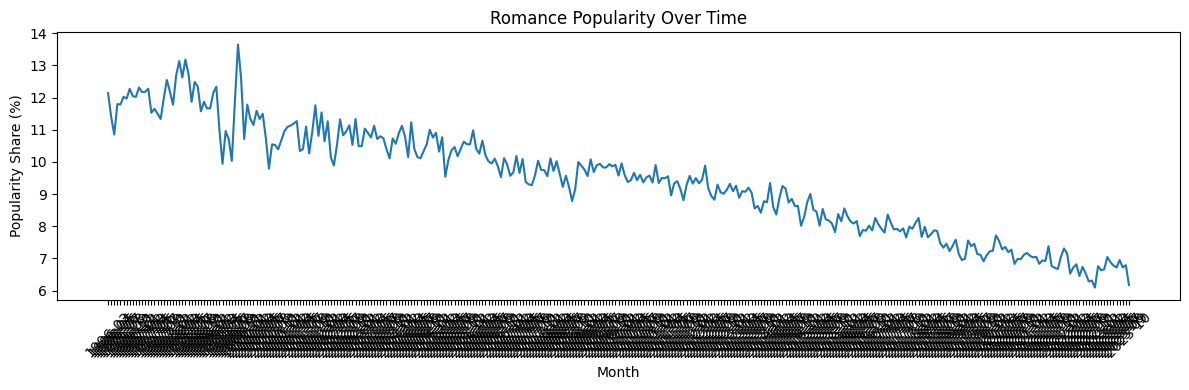

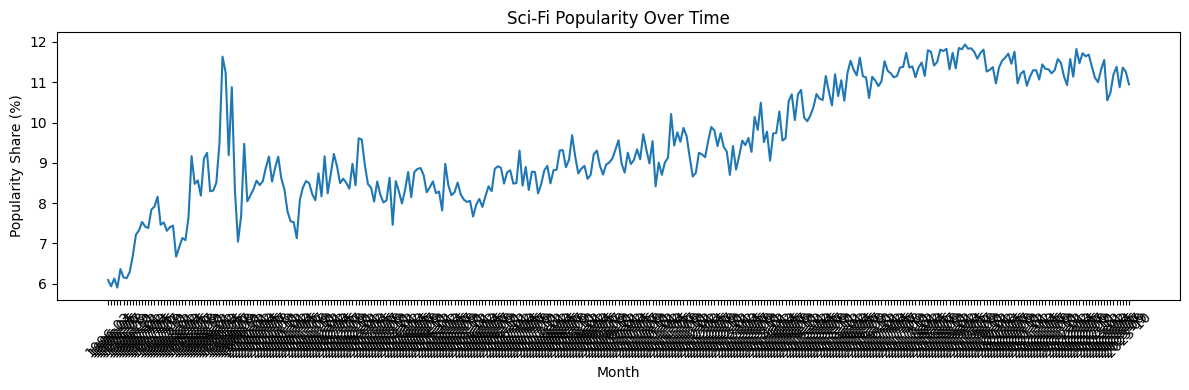

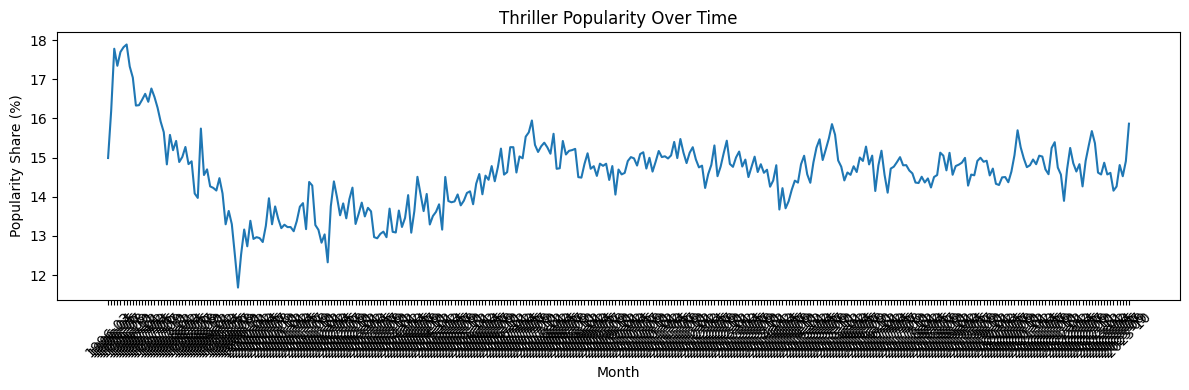

In [30]:
for genre in ts.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(ts.index.astype(str), ts[genre])
    plt.title(f"{genre} Popularity Over Time")
    plt.xlabel("Month")
    plt.ylabel("Popularity Share (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

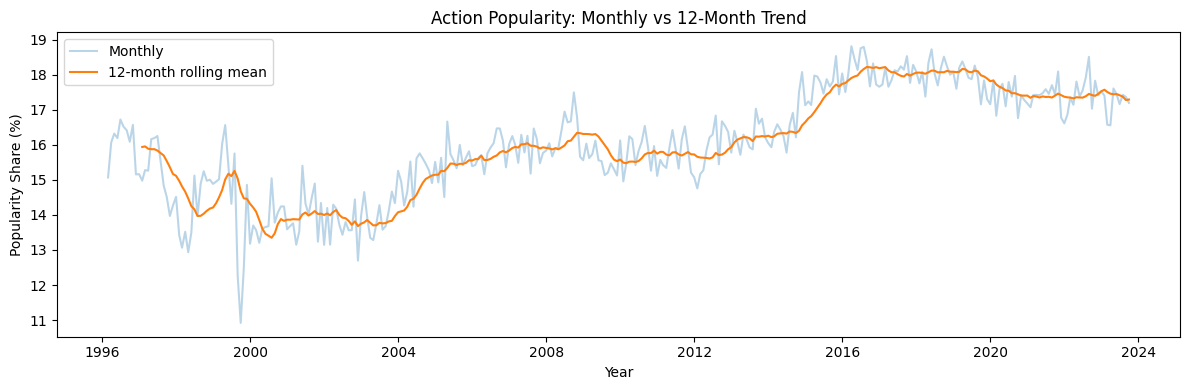

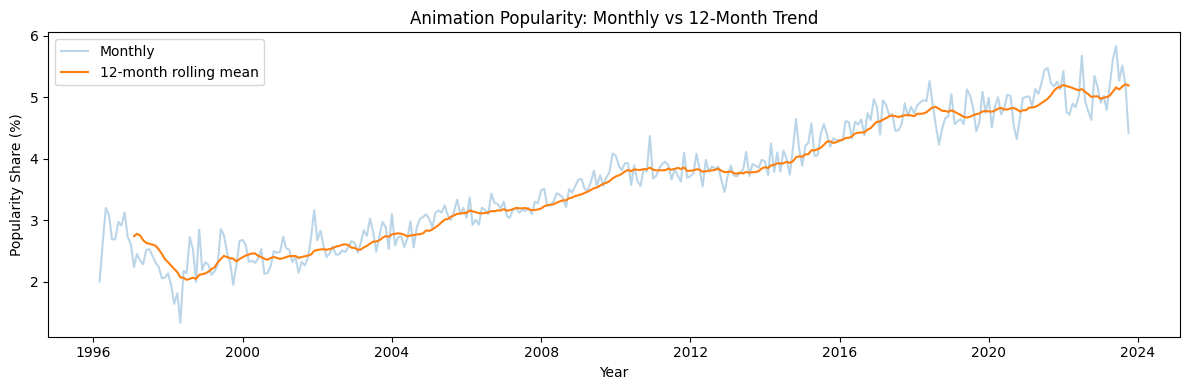

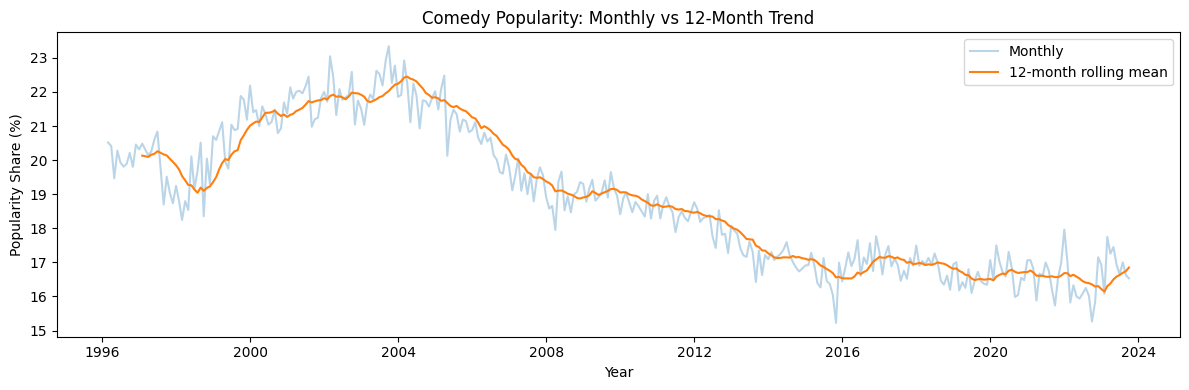

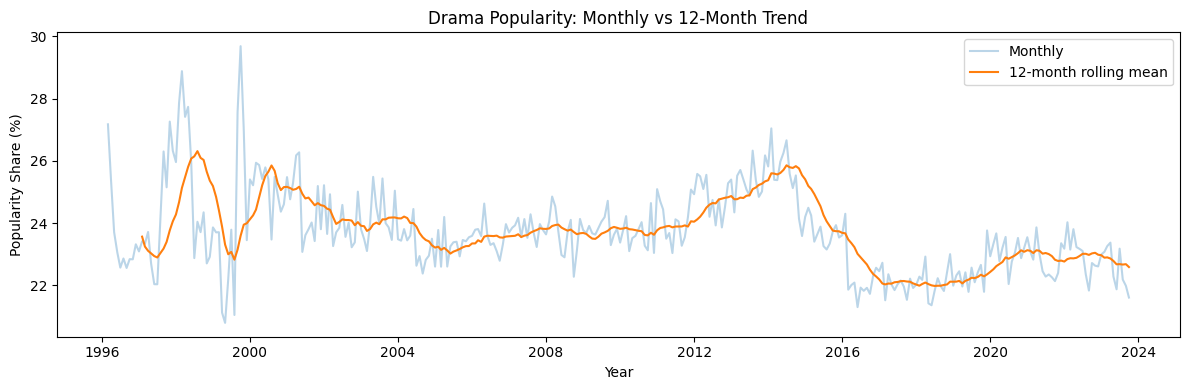

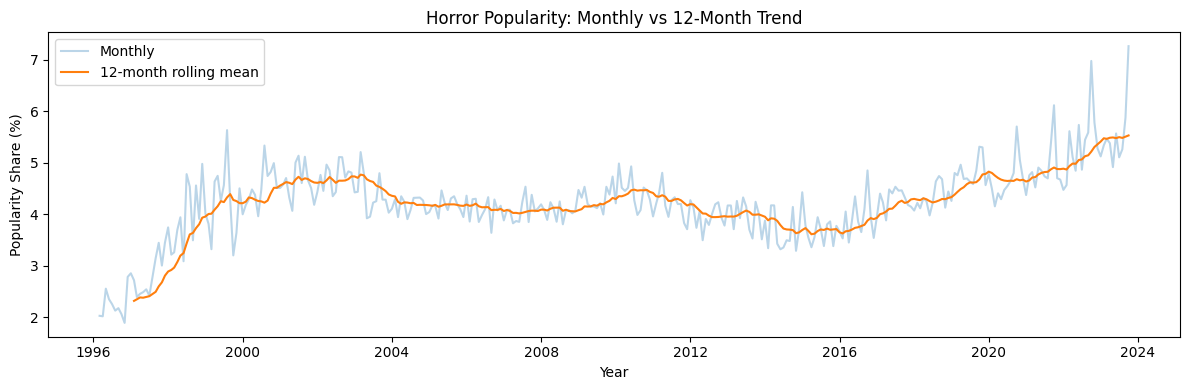

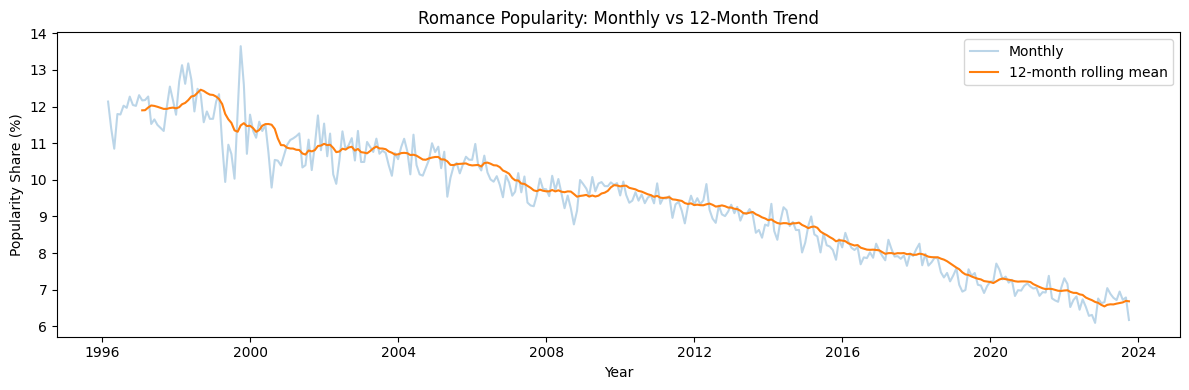

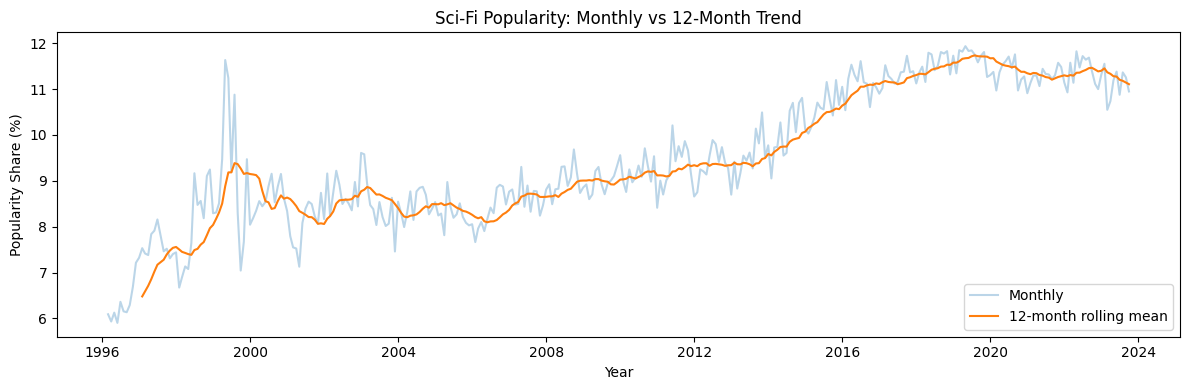

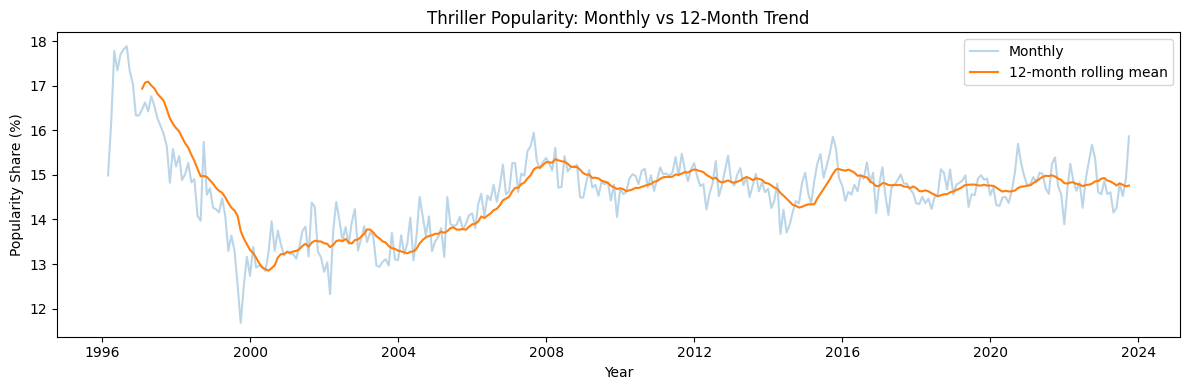

In [31]:
for genre in ts.columns:
    rolling = ts[genre].rolling(12).mean()

    plt.figure(figsize=(12, 4))
    plt.plot(ts.index.to_timestamp(), ts[genre], alpha=0.3, label="Monthly")
    plt.plot(rolling.index.to_timestamp(), rolling, label="12-month rolling mean")

    plt.title(f"{genre} Popularity: Monthly vs 12-Month Trend")
    plt.xlabel("Year")
    plt.ylabel("Popularity Share (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

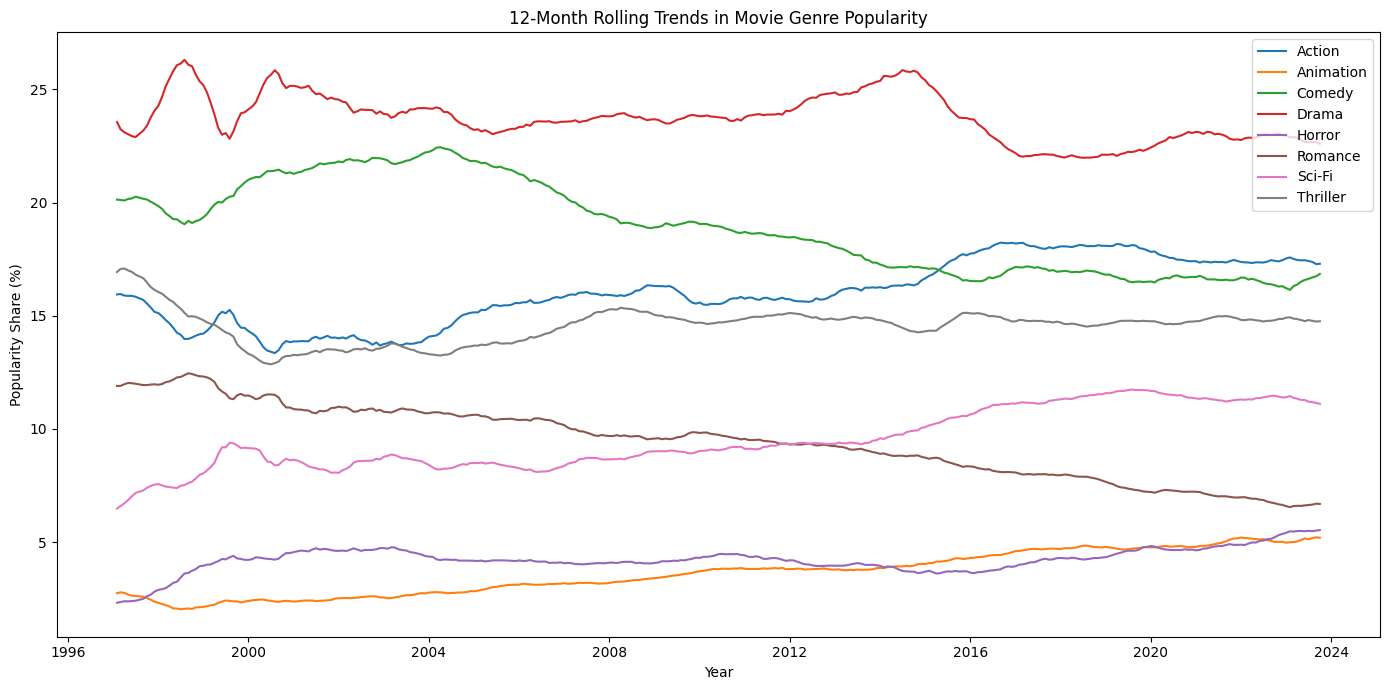

In [32]:
rolling_ts = ts.rolling(12).mean()

plt.figure(figsize=(14, 7))

for genre in rolling_ts.columns:
    plt.plot(
        rolling_ts.index.to_timestamp(),
        rolling_ts[genre],
        label=genre
    )

plt.title("12-Month Rolling Trends in Movie Genre Popularity")
plt.xlabel("Year")
plt.ylabel("Popularity Share (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
seasonal = ts.copy()

seasonal["month_num"] = seasonal.index.month

seasonal_avg = (
    seasonal
    .groupby("month_num")[ts.columns.tolist()]
    .mean()
)

print(seasonal_avg)

genres        Action  Animation     Comedy      Drama    Horror   Romance  \
month_num                                                                   
1          15.841934   3.679818  19.093977  23.892511  4.170410  9.522422   
2          15.848830   3.582402  18.854457  24.064514  4.192500  9.578544   
3          15.789654   3.536434  19.093644  24.123410  4.136309  9.644991   
4          15.894368   3.602278  19.004587  23.918844  4.188285  9.520325   
5          16.223996   3.561309  18.742531  23.749426  4.103908  9.367429   
6          16.141229   3.721365  18.995831  23.431191  4.137106  9.453369   
7          16.217823   3.703389  18.914816  23.393850  4.184039  9.343072   
8          16.243224   3.673468  18.793808  23.374625  4.346042  9.224104   
9          16.228078   3.560015  18.677943  23.610472  4.289495  9.256908   
10         16.073617   3.568607  18.726729  23.487240  4.568302  9.298398   
11         16.120984   3.688176  18.710901  23.691118  4.144875  9.417483   

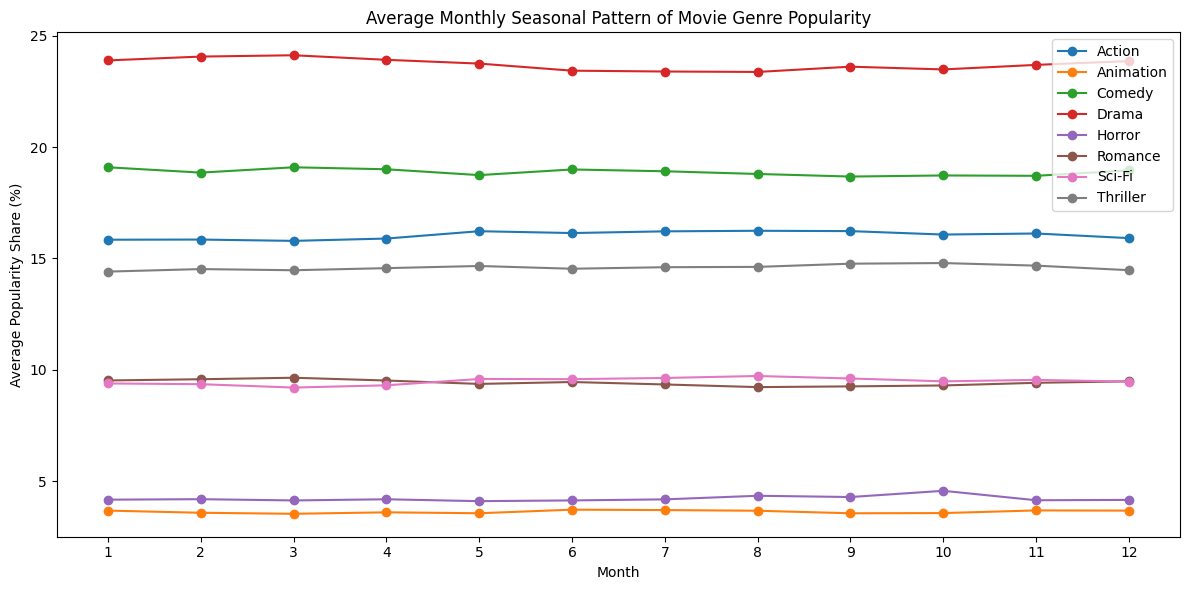

In [34]:
plt.figure(figsize=(12, 6))

for genre in ts.columns:
    plt.plot(
        seasonal_avg.index,
        seasonal_avg[genre],
        marker="o",
        label=genre
    )

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average Popularity Share (%)")
plt.title("Average Monthly Seasonal Pattern of Movie Genre Popularity")
plt.legend()
plt.tight_layout()
plt.show()

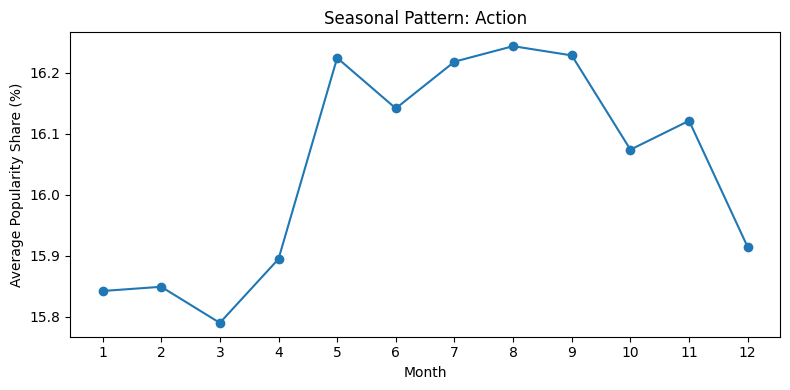

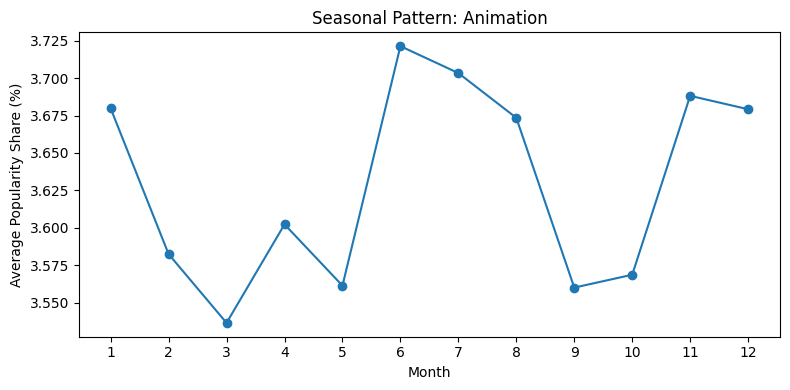

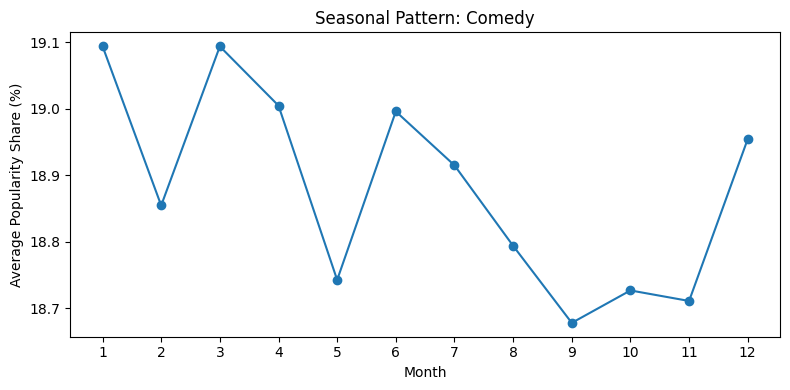

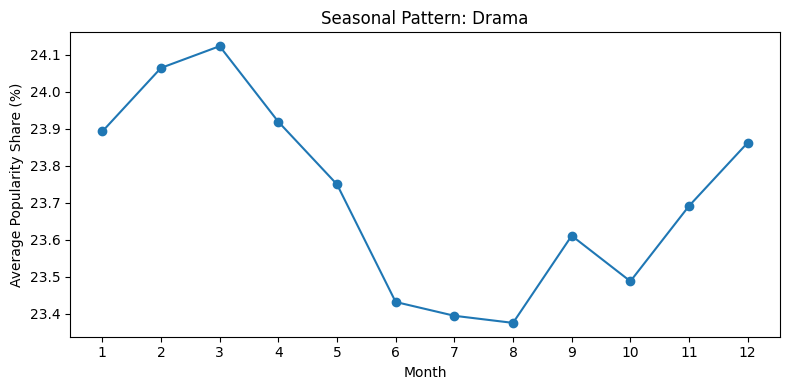

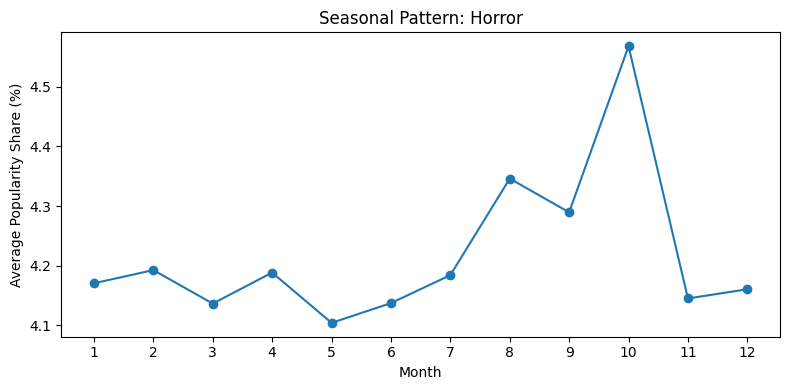

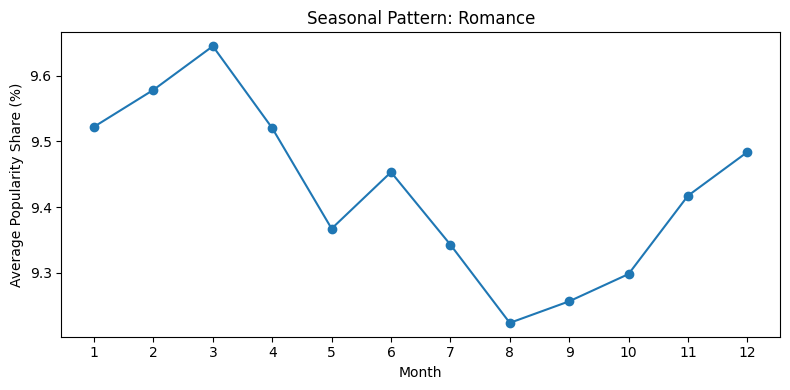

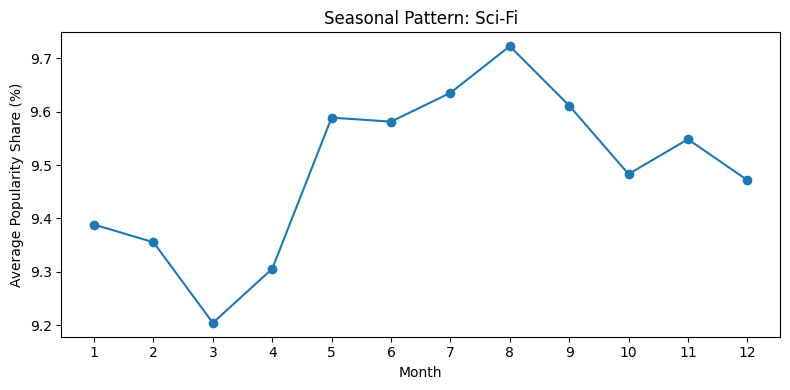

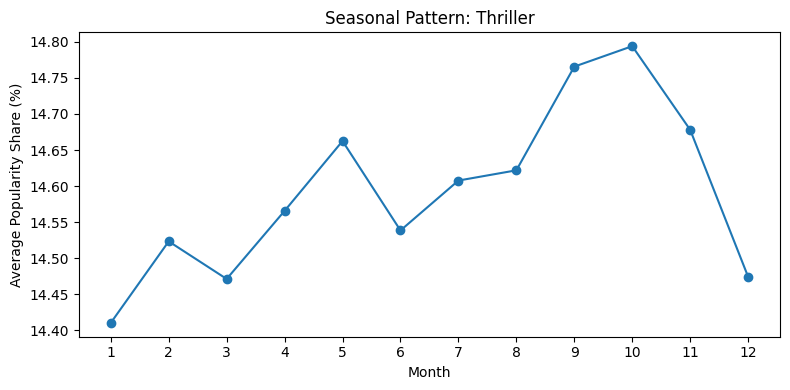

In [35]:
for genre in ts.columns:
    plt.figure(figsize=(8, 4))

    plt.plot(
        seasonal_avg.index,
        seasonal_avg[genre],
        marker="o"
    )

    plt.xticks(range(1, 13))
    plt.xlabel("Month")
    plt.ylabel("Average Popularity Share (%)")
    plt.title(f"Seasonal Pattern: {genre}")
    plt.tight_layout()
    plt.show()

In [36]:
seasonality_strength = {}

for genre in ts.columns:
    monthly_values = seasonal_avg[genre]

    seasonality_strength[genre] = (
        monthly_values.max() - monthly_values.min()
    )

print(
    pd.Series(seasonality_strength)
    .sort_values(ascending=False)
)

Drama        0.748784
Sci-Fi       0.518565
Horror       0.464393
Action       0.453569
Romance      0.420888
Comedy       0.416034
Thriller     0.383612
Animation    0.184930
dtype: float64


In [37]:
from statsmodels.tsa.seasonal import STL

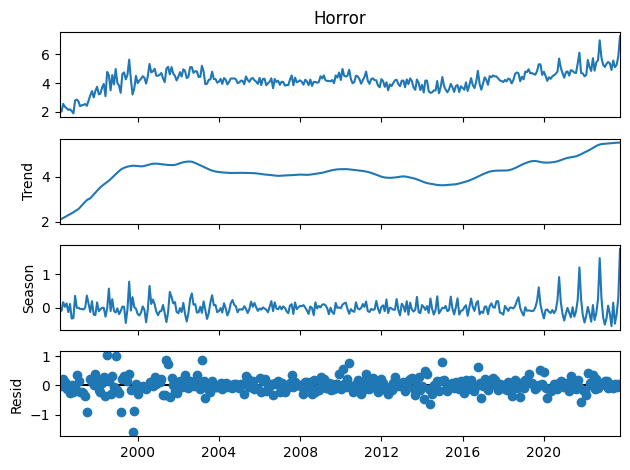

In [38]:
from statsmodels.tsa.seasonal import STL

horror = ts["Horror"].copy()

# Convert monthly PeriodIndex to Timestamp
horror.index = horror.index.to_timestamp()

result = STL(
    horror,
    period=12,
    robust=True
).fit()

result.plot()
plt.tight_layout()
plt.show()

In [39]:
seasonal_strength = {}

for genre in ts.columns:
    series = ts[genre].copy()
    series.index = series.index.to_timestamp()

    result = STL(
        series,
        period=12,
        robust=True
    ).fit()

    seasonal_var = result.seasonal.var()
    residual_var = result.resid.var()

    seasonal_strength[genre] = (
        seasonal_var / (seasonal_var + residual_var)
    )

print(
    pd.Series(seasonal_strength)
    .sort_values(ascending=False)
)

Animation    0.455445
Horror       0.449499
Comedy       0.289242
Action       0.275319
Romance      0.264035
Thriller     0.256236
Drama        0.230725
Sci-Fi       0.196132
dtype: float64


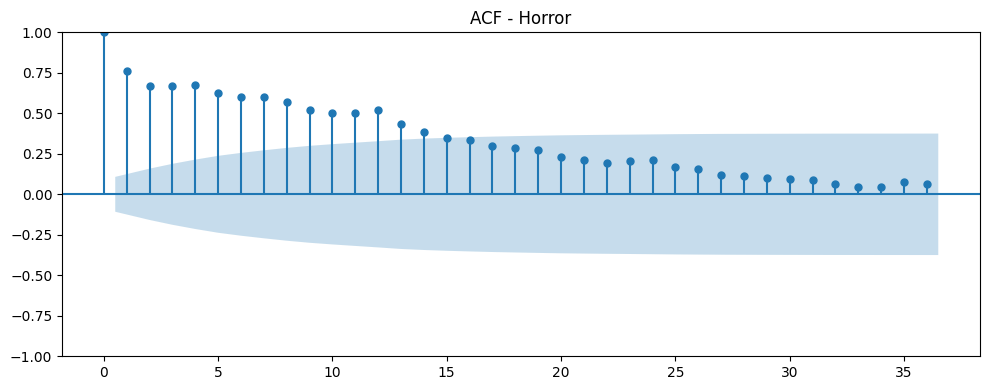

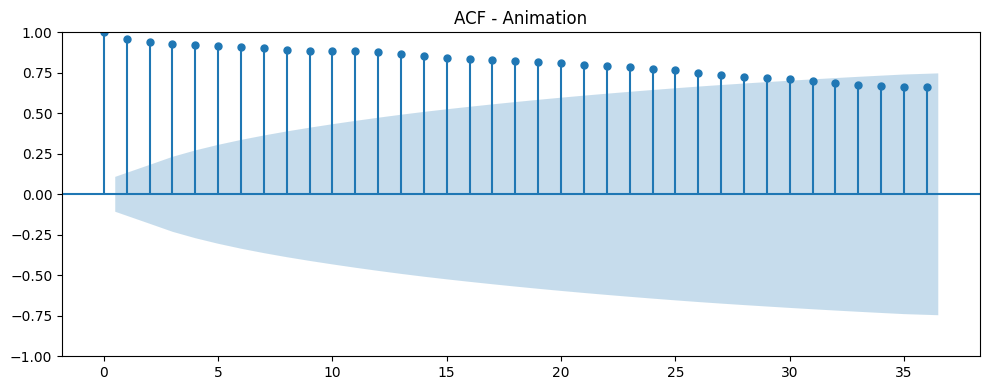

In [40]:
from statsmodels.graphics.tsaplots import plot_acf

for genre in ["Horror", "Animation"]:
    plt.figure(figsize=(10, 4))

    plot_acf(
        ts[genre],
        lags=36,
        ax=plt.gca()
    )

    plt.title(f"ACF - {genre}")
    plt.tight_layout()
    plt.show()

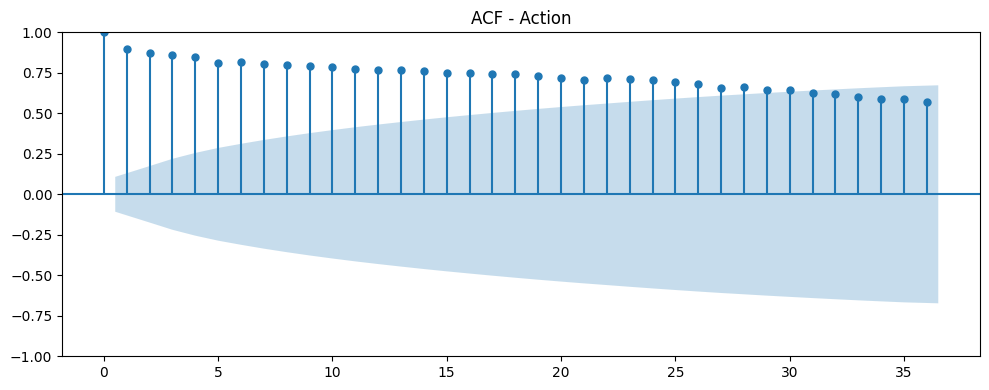

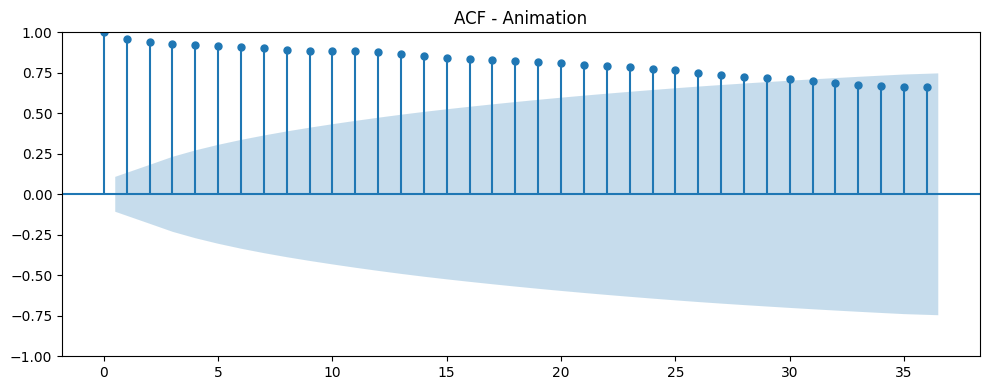

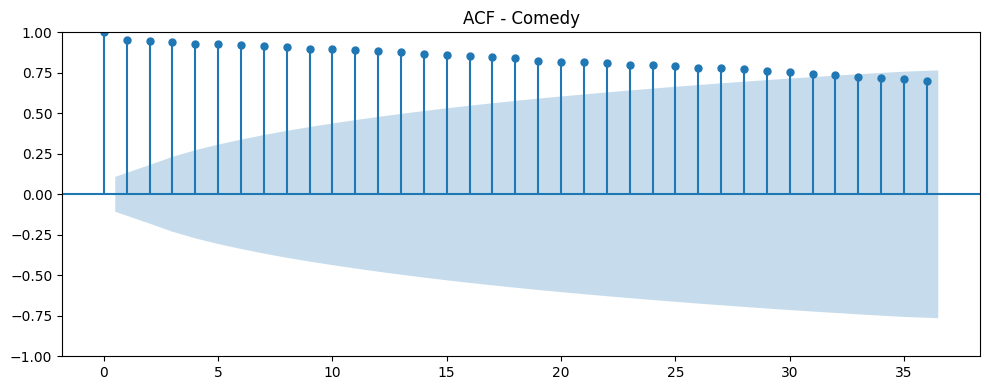

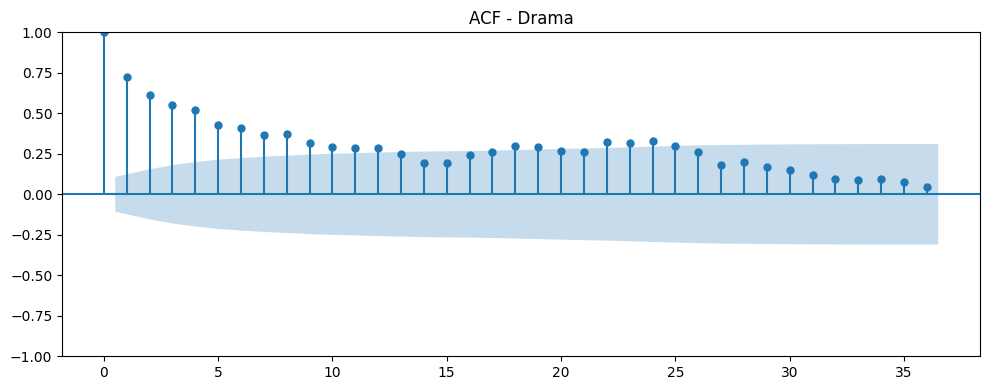

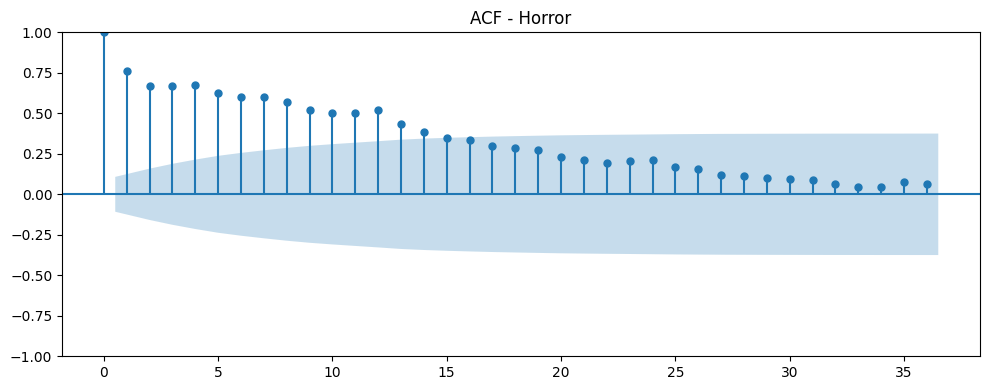

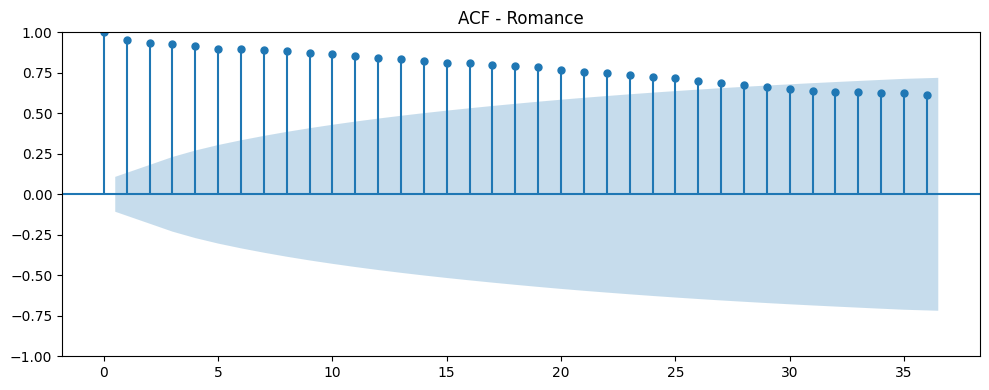

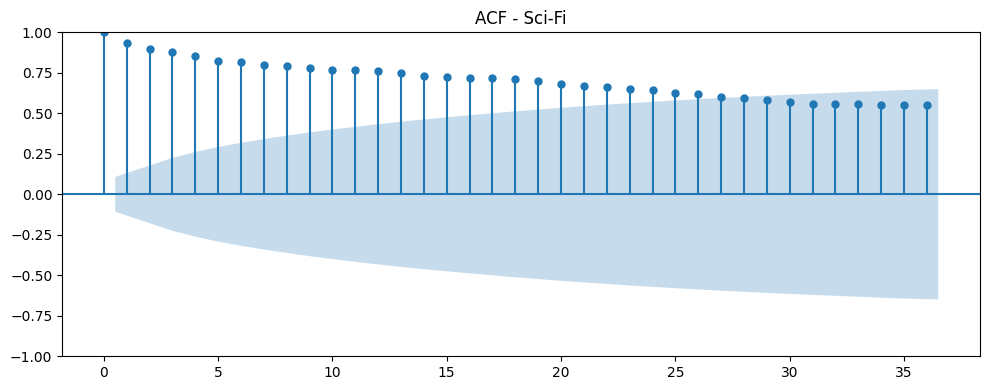

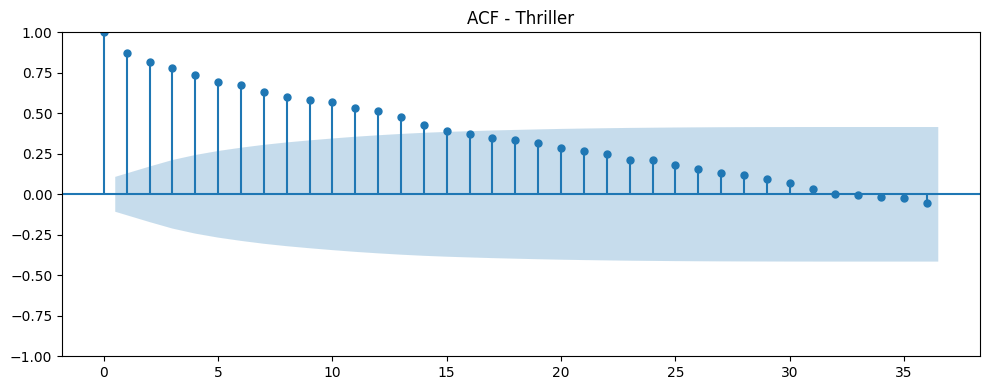

In [41]:
for genre in ts.columns:
    plt.figure(figsize=(10, 4))

    plot_acf(
        ts[genre],
        lags=36,
        ax=plt.gca()
    )

    plt.title(f"ACF - {genre}")
    plt.tight_layout()
    plt.show()

In [42]:
from statsmodels.tsa.stattools import acf

acf_results = {}

for genre in ts.columns:
    values = acf(ts[genre], nlags=36, fft=True)

    acf_results[genre] = {
        "Lag 1": values[1],
        "Lag 3": values[3],
        "Lag 6": values[6],
        "Lag 12": values[12],
        "Lag 24": values[24],
        "Lag 36": values[36]
    }

acf_table = pd.DataFrame(acf_results).T

print(acf_table.round(3))

           Lag 1  Lag 3  Lag 6  Lag 12  Lag 24  Lag 36
Action     0.898  0.862  0.815   0.767   0.703   0.568
Animation  0.958  0.928  0.907   0.877   0.776   0.665
Comedy     0.953  0.943  0.925   0.885   0.801   0.701
Drama      0.725  0.550  0.411   0.286   0.328   0.042
Horror     0.762  0.672  0.603   0.523   0.211   0.062
Romance    0.955  0.928  0.896   0.842   0.725   0.610
Sci-Fi     0.931  0.876  0.815   0.758   0.641   0.552
Thriller   0.874  0.781  0.674   0.511   0.213  -0.051


In [43]:
import numpy as np

n = len(ts)

acf_limit = 1.96 / np.sqrt(n)

print("Approximate 95% ACF significance limit:", round(acf_limit, 3))

Approximate 95% ACF significance limit: 0.108
